In [1]:
import os
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.signal import find_peaks
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import rfft, rfftfreq
import pywt

In [2]:
def extract_wavelet_features(signal, wavelet='db4', level=3):
    features = []

    coeffs = pywt.wavedec(signal, wavelet, level=level)

    # coeffs[0] = aproximação
    # coeffs[1:] = detalhes

    for coeff in coeffs:
        energy = np.sum(coeff**2)
        features.append(energy)

    return features

In [3]:
def extract_features(signal):
    features = []

    features.append(np.mean(signal))
    features.append(np.std(signal))
    features.append(np.min(signal))
    features.append(np.max(signal))
    features.append(np.ptp(signal))  # peak-to-peak
    features.append(np.sum(signal**2))  # energia
    features.append(skew(signal))
    features.append(kurtosis(signal))

    peaks, _ = find_peaks(signal)
    features.append(len(peaks))  # número de picos

    features.append(len(signal))  # duração

    return features

In [4]:
def extract_clinical_features(signal, fs=360):
    features = []

    signal = signal.astype(np.float32)

    # ----- Estatísticas -----
    features.extend([
        np.mean(signal),
        np.std(signal),
        np.min(signal),
        np.max(signal),
        np.ptp(signal),
        np.sum(signal**2),
        np.sum(np.abs(signal)),
        np.max(np.abs(np.diff(signal))),
        len(signal),
        skew(signal),
        kurtosis(signal)
    ])

    # ----- Pico R -----
    peaks, _ = find_peaks(signal, distance=50)

    if len(peaks) > 0:
        r_peak_amp = np.max(signal[peaks])
        features.append(r_peak_amp)
    else:
        features.append(0)

    # ----- QRS width -----
    if len(peaks) > 0:
        peak = peaks[np.argmax(signal[peaks])]
        threshold = signal[peak] * 0.5

        left = peak
        while left > 0 and signal[left] > threshold:
            left -= 1

        right = peak
        while right < len(signal)-1 and signal[right] > threshold:
            right += 1

        qrs_width = (right - left) / fs
        features.append(qrs_width)
    else:
        features.append(0)

    # ----- FFT dominante -----
    yf = np.abs(rfft(signal))
    xf = rfftfreq(len(signal), 1/fs)

    dominant_freq = xf[np.argmax(yf)]
    spectral_energy = np.sum(yf)

    features.append(dominant_freq)
    features.append(spectral_energy)

     # Spectral bands
    features.extend(spectral_band_features(signal, fs))

    # ----- WAVELET -----
    wavelet_features = extract_wavelet_features(signal, wavelet='db4', level=4)
    features.extend(wavelet_features)

    return features

In [5]:
def spectral_band_features(signal, fs=360):

    yf = np.abs(np.fft.rfft(signal))
    xf = np.fft.rfftfreq(len(signal), 1/fs)

    band1 = yf[(xf >= 0) & (xf < 5)].sum()
    band2 = yf[(xf >= 5) & (xf < 15)].sum()
    band3 = yf[(xf >= 15) & (xf < 40)].sum()

    return [band1, band2, band3]

In [6]:
def build_dataset(root_dir):
    X = []
    y = []

    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)

        if not os.path.isdir(class_path):
            continue

        for file in os.listdir(class_path):
            if not file.endswith(".csv"):
                continue

            file_path = os.path.join(class_path, file)

            df = pd.read_csv(file_path)

            # Detecta coluna correta
            if "amplitude" in df.columns:
                signal = df["amplitude"].values
            elif "channel_0" in df.columns:
                signal = df["channel_0"].values
            else:
                signal = df.values.flatten()

            signal = signal.astype(np.float32)

            features = extract_clinical_features(signal)

            X.append(features)
            y.append(class_name)

    return np.array(X), np.array(y)

In [9]:
import torch
import torch.nn as nn
from sklearn.preprocessing import LabelEncoder
from kan import KAN
from sklearn.utils.class_weight import compute_class_weight
# 1. Carregar os dados (mesmo código seu)
X_train, y_train = build_dataset("dataset_split_2/train")
X_val, y_val = build_dataset("dataset_split_2/val")

print("Features por amostra:", X_train.shape[1])

# 2. Converter as letras originais para números (0 a 7)
encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(y_train)
y_val_enc = encoder.transform(y_val)
num_classes = len(encoder.classes_)

# 3. Transformar os arrays numpy em Tensores do PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train_enc, dtype=torch.long) # .long é exigido para classificação
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val_enc, dtype=torch.long)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Escalonando os dados de treino e validação
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Convertendo para tensores PyTorch
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)

Features por amostra: 23


In [12]:
# 4. Criar a arquitetura KAN
# width: [entrada (23), camada oculta (64), saída (8 classes)]
model = KAN(width=[X_train.shape[1], 64, 32, num_classes], grid=5, k=3)

# 5. Dicionário de dados no formato exigido pela biblioteca
dataset = {
    'train_input': X_train_t,
    'train_label': y_train_t,
    'test_input': X_val_t,
    'test_label': y_val_t
}

# Métrica para acompanhar a acurácia no console
def accuracy(pred, target):
    return (torch.argmax(pred, dim=1) == target).float().mean()

# 1. Calcula os pesos baseados no desbalanceamento do treino
pesos_classes = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(y_train_enc), 
    y=y_train_enc
)

# 2. Converte para tensor e passa para a função de perda
pesos_tensor = torch.tensor(pesos_classes, dtype=torch.float32)
loss_fn = nn.CrossEntropyLoss(weight=pesos_tensor)

# 6. Treinar o modelo usando CrossEntropyLoss e Adam (com batch)
# 6. Treinar o modelo usando CrossEntropyLoss e Adam (com batch)
results = model.fit(
    dataset,
    opt="Adam",
    steps=25000,           # Quantidade de épocas
    lr=0.001,             # Taxa de aprendizado
    loss_fn=loss_fn,
    batch=512            # Essencial para datasets grandes
)

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.39e-01 | test_loss: 4.60e-01 | reg: 7.56e+02 | : 100%|█| 25000/25000 [17:42<00:00, 2


saving model version 0.1


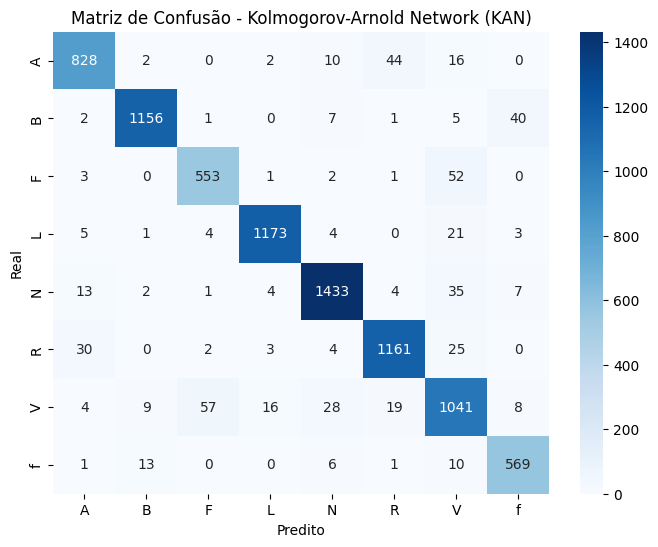

              precision    recall  f1-score   support

           A     0.9345    0.9180    0.9262       902
           B     0.9772    0.9538    0.9653      1212
           F     0.8948    0.9036    0.8992       612
           L     0.9783    0.9686    0.9734      1211
           N     0.9592    0.9560    0.9576      1499
           R     0.9431    0.9478    0.9454      1225
           V     0.8639    0.8807    0.8722      1182
           f     0.9075    0.9483    0.9275       600

    accuracy                         0.9373      8443
   macro avg     0.9323    0.9346    0.9334      8443
weighted avg     0.9379    0.9373    0.9375      8443



In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 7. Fazer as predições no conjunto de validação
with torch.no_grad(): # Desliga o cálculo de gradientes para economizar memória
    y_pred_logits = model(X_val_t)
    y_pred_idx = torch.argmax(y_pred_logits, dim=1).numpy()

# 8. Converter os índices (0 a 7) de volta para as letras das classes
y_pred_labels = encoder.inverse_transform(y_pred_idx)

# 9. Plotar a Matriz de Confusão
cm = confusion_matrix(y_val, y_pred_labels)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    cmap="Blues"
)
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Kolmogorov-Arnold Network (KAN)")
plt.show()

# 10. Relatório final de métricas
print(classification_report(y_val, y_pred_labels, digits=4))